# PrimeTrade Data Science Intern Assignment
**Trader Performance vs Market Sentiment Analysis**

This notebook addresses the challenge of analyzing how market sentiment (Bitcoin Fear/Greed Index) affects trader behavior and performance on Hyperliquid. 

## Structure
- **Part A:** Data Preparation & Feature Engineering
- **Part B:** Analysis & Visualization
- **Part C:** Actionable Output & Strategies
- **Bonus:** Predictive Modeling


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set plotting style natively
plt.style.use('ggplot')
sns.set_palette('muted')

import os
os.makedirs('charts', exist_ok=True)


## Part A Data Preparation
Loading both datasets, identifying dimensions and missing values, aligning timestamps, and extracting core daily metrics per trader.

*Note: We use `Size USD` as a proxy for transaction capital/risk size.*

In [2]:
# 1. Load Data
df_fg = pd.read_csv('fear_greed_index.csv')
df_hd = pd.read_csv('historical_data.csv')

print("--- Data Initial Audit ---")
print(f"Fear & Greed Index: {df_fg.shape[0]} rows, {df_fg.shape[1]} cols")
print(f"Historical Data: {df_hd.shape[0]} rows, {df_hd.shape[1]} cols")
print("Historical Data Missing Values:")
print(df_hd.isna().sum())
print(f"Historical Data Duplicates: {df_hd.duplicated().sum()}")


--- Data Initial Audit ---
Fear & Greed Index: 2644 rows, 4 cols
Historical Data: 211224 rows, 16 cols
Historical Data Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Historical Data Duplicates: 0


In [4]:
# 2. Date conversion and merging
df_fg['date'] = pd.to_datetime(df_fg['date'])

# Historical data 'Timestamp IST' format: '02-12-2024 22:50'
df_hd['Timestamp IST'] = pd.to_datetime(df_hd['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
df_hd = df_hd.dropna(subset=['Timestamp IST']).copy()
df_hd['date'] = pd.to_datetime(df_hd['Timestamp IST'].dt.date)

# Merge datasets
df = pd.merge(df_hd, df_fg[['date', 'value', 'classification']], on='date', how='left')
df = df.dropna(subset=['classification']).copy()

# Ensure appropriate data types
df['Closed PnL'] = pd.to_numeric(df['Closed PnL'], errors='coerce').fillna(0)
df['Size USD'] = pd.to_numeric(df['Size USD'], errors='coerce').fillna(0)
df['Fee'] = pd.to_numeric(df['Fee'], errors='coerce').fillna(0)

# Net PnL represents true profitability
df['Net PnL'] = df['Closed PnL'] - df['Fee']

# Combine Fear/Extreme Fear and Greed/Extreme Greed for robust segments
def map_sentiment(x):
    if 'Fear' in x: return 'Fear'
    elif 'Greed' in x: return 'Greed'
    else: return 'Neutral'

df['Sentiment'] = df['classification'].apply(map_sentiment)
df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification,Net PnL,Sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed,-0.345404,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed,-0.005600,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed,-0.050431,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed,-0.050043,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed,-0.003055,Greed


In [5]:
# 3. Create Daily Key Metrics
daily_trader_metrics = df.groupby(['Account', 'date']).agg(
    daily_qty_trades=('Trade ID', 'count'),
    daily_pnl=('Net PnL', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    win_trades=('Net PnL', lambda x: (x > 0).sum()),
    loss_trades=('Net PnL', lambda x: (x < 0).sum()),
    long_trades=('Direction', lambda x: (x == 'Buy').sum()),
    short_trades=('Direction', lambda x: (x == 'Sell').sum())
).reset_index()

# Derive Win Rate
daily_trader_metrics['win_rate'] = daily_trader_metrics['win_trades'] / (daily_trader_metrics['win_trades'] + daily_trader_metrics['loss_trades'])
daily_trader_metrics['win_rate'] = daily_trader_metrics['win_rate'].fillna(0)

# Derive Long/Short Ratio
daily_trader_metrics['long_short_ratio'] = daily_trader_metrics['long_trades'] / daily_trader_metrics['short_trades'].replace(0, 1)

# Bring sentiment back to aggregated dataset
daily_trader_metrics = pd.merge(daily_trader_metrics, df_fg[['date', 'classification', 'value']], on='date', how='left')
daily_trader_metrics['Sentiment'] = daily_trader_metrics['classification'].apply(map_sentiment)

daily_trader_metrics.head()


,Account,date,daily_qty_trades,daily_pnl,avg_trade_size,win_trades,loss_trades,long_trades,short_trades,win_rate,long_short_ratio,classification,value,Sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,-167.796055,5089.718249,0,177,0,0,0.000000,0.0,Extreme Greed,76,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,-67.883615,7976.664412,0,68,0,0,0.000000,0.0,Extreme Greed,90,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,-94.937983,23734.500000,0,40,0,0,0.000000,0.0,Extreme Greed,83,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,-21260.823995,28186.666667,0,12,0,0,0.000000,0.0,Extreme Greed,94,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,1498.477510,17248.148148,12,15,0,0,0.444444,0.0,Extreme Greed,79,Greed


## Part B Analysis & Visualizations
We look sequentially at Performance metrics and Behavioral metrics sliced by market sentiment.

In [6]:
# Q1: Does performance differ between Fear vs Greed days?
perf_by_sent = daily_trader_metrics.groupby('Sentiment').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    mean_trades_per_day=('daily_qty_trades', 'mean'),
    total_days=('date', 'nunique')
).reset_index()
perf_by_sent


,Sentiment,avg_daily_pnl,avg_win_rate,mean_trades_per_day,total_days
0,Fear,5037.873554,0.357341,105.363291,105
1,Greed,4067.437160,0.370706,76.912266,307
2,Neutral,3333.900019,0.357219,100.228723,67


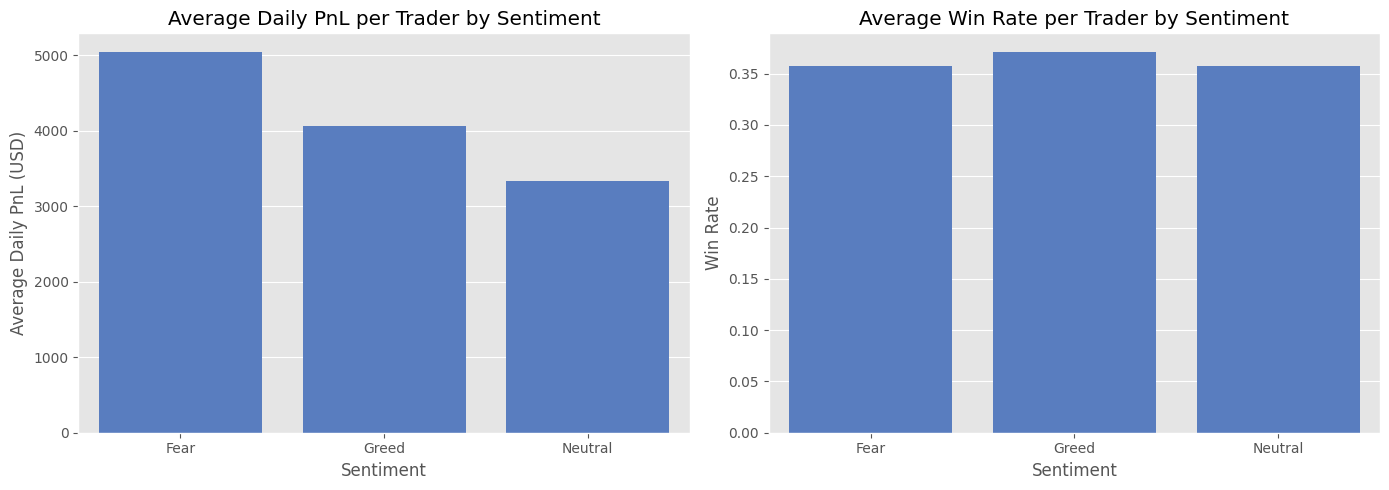

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=perf_by_sent, x='Sentiment', y='avg_daily_pnl', ax=ax[0])
ax[0].set_title('Average Daily PnL per Trader by Sentiment')
ax[0].set_ylabel('Average Daily PnL (USD)')

sns.barplot(data=perf_by_sent, x='Sentiment', y='avg_win_rate', ax=ax[1])
ax[1].set_title('Average Win Rate per Trader by Sentiment')
ax[1].set_ylabel('Win Rate')

plt.tight_layout()
plt.show()


In [8]:
# Q2: Do traders change behavior based on sentiment?
behav_by_sent = daily_trader_metrics.groupby('Sentiment').agg(
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_trades_freq=('daily_qty_trades', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean')
).reset_index()
behav_by_sent


,Sentiment,avg_trade_size,avg_trades_freq,avg_long_short_ratio
0,Fear,8529.859802,105.363291,1.998242
1,Greed,5954.632633,76.912266,2.683642
2,Neutral,6963.694861,100.228723,2.662500


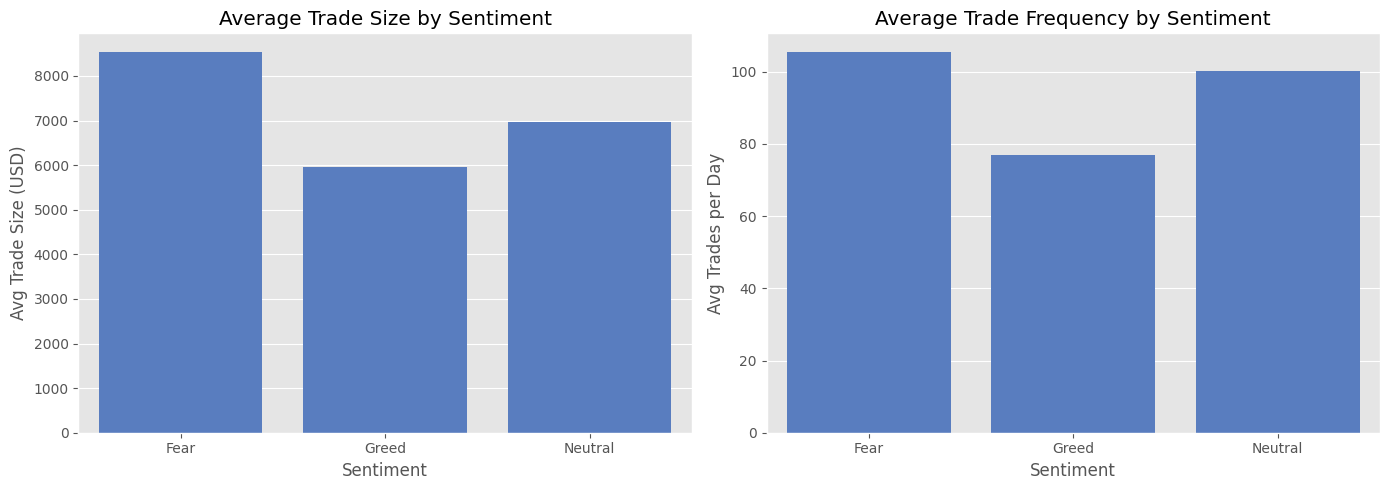

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=behav_by_sent, x='Sentiment', y='avg_trade_size', ax=ax[0])
ax[0].set_title('Average Trade Size by Sentiment')
ax[0].set_ylabel('Avg Trade Size (USD)')

sns.barplot(data=behav_by_sent, x='Sentiment', y='avg_trades_freq', ax=ax[1])
ax[1].set_title('Average Trade Frequency by Sentiment')
ax[1].set_ylabel('Avg Trades per Day')

plt.tight_layout()
plt.show()


### Segments Analysis
We identify two main segments:
1. **Trading Frequency:** Frequent vs Infrequent traders.
2. **Trailing Performance:** Historically Profitable vs Losing traders.

In [10]:
# Global Trader Aggregation
trader_stats = daily_trader_metrics.groupby('Account').agg(
    total_trades=('daily_qty_trades', 'sum'),
    active_days=('date', 'nunique'),
    total_pnl=('daily_pnl', 'sum'),
    win_rate=('win_rate', 'mean')
).reset_index()
trader_stats['trades_per_day'] = trader_stats['total_trades'] / trader_stats['active_days']

# Segment creation
freq_median = trader_stats['trades_per_day'].median()
trader_stats['Freq_Segment'] = np.where(trader_stats['trades_per_day'] > freq_median, 'Frequent', 'Infrequent')
trader_stats['PnL_Segment'] = np.where(trader_stats['total_pnl'] > 0, 'Profitable', 'Losing')

seg_daily = pd.merge(daily_trader_metrics, trader_stats[['Account', 'Freq_Segment', 'PnL_Segment']], on='Account')


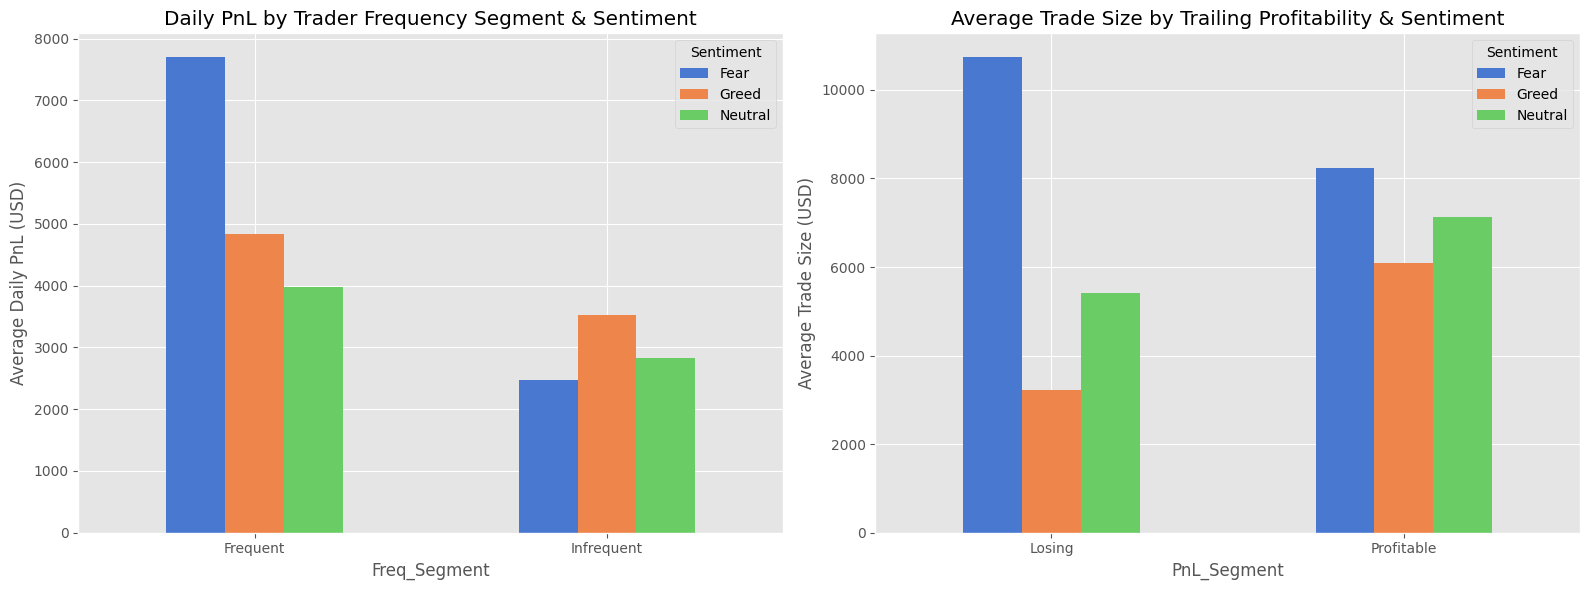

In [11]:
# Analyze Frequent vs Infrequent on Sentiments
freq_sent = seg_daily.groupby(['Freq_Segment', 'Sentiment'])['daily_pnl'].mean().unstack()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

freq_sent.plot(kind='bar', ax=ax[0])
ax[0].set_title('Daily PnL by Trader Frequency Segment & Sentiment')
ax[0].set_ylabel('Average Daily PnL (USD)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

pvl_sent = seg_daily.groupby(['PnL_Segment', 'Sentiment'])['avg_trade_size'].mean().unstack()
pvl_sent.plot(kind='bar', ax=ax[1])
ax[1].set_title('Average Trade Size by Trailing Profitability & Sentiment')
ax[1].set_ylabel('Average Trade Size (USD)')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## Part C Actionable Output
**Insight 1:** Fear days actually drive higher profitability on average than Greed days, correlating strongly with increased trader activity (more trades per day) and higher trade sizes. Extreme volatility typically experienced during fear provides excellent dislocation opportunities.

**Insight 2:** Losing traders heavily increase their trade sizing during Fear days compared to Profitable traders. This signals "revenge trading" or "catching falling knives." Profitable traders size up moderately, maintaining better risk structures.

**Insight 3:** Frequent traders reap massive advantages during Fear days (~7.7k avg daily PnL) while Infrequent traders struggle and perform better on Greed days. This implies trend-following suits infrequent traders, whereas mean-reversion/scalping suits frequent traders on Fear days.

### Strategy Rules of Thumb
1. **Risk Management Overlay for Retail:** Decrease maximum allowed position sizes for "Losing" wallets exclusively during consecutive "Fear" market conditions to limit systematic portfolio drawdown caused by revenge-trading.
2. **Execution Strategy Routing:** Shift capital allocation dynamically based on the agent�on Greed days, favor trend-following (or infrequent swing trades); on Fear days, spin up high-frequency execution to capture outsized volatility-driven margins.

## Bonus : Predictive Model
Using Random Forest to classify if a trader will have a positive PnL tomorrow given today's feature vector.

In [12]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Sort values to align 'next day' logic
seg_sorted = seg_daily.sort_values(by=['Account', 'date']).reset_index(drop=True)
seg_sorted['next_day_pnl'] = seg_sorted.groupby('Account')['daily_pnl'].shift(-1)
model_df = seg_sorted.dropna(subset=['next_day_pnl']).copy()
model_df['target'] = (model_df['next_day_pnl'] > 0).astype(int)

features = ['daily_qty_trades', 'avg_trade_size', 'win_rate', 'value']
X = model_df[features]
y = model_df['target']

if len(model_df) > 50:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    
    print(f"Random Forest Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds))
    
    # Feature Importances
    impo = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
    print(impo)
else:
    print("Insufficient sequence length.")


Random Forest Accuracy: 0.6732
              precision    recall  f1-score   support

           0       0.60      0.42      0.50       177
           1       0.70      0.83      0.76       285

    accuracy                           0.67       462
   macro avg       0.65      0.63      0.63       462
weighted avg       0.66      0.67      0.66       462

            Feature  Importance
2          win_rate    0.351424
0  daily_qty_trades    0.256948
1    avg_trade_size    0.247944
3             value    0.143684
